Found 3091 images belonging to 3 classes.
Found 926 images belonging to 3 classes.
Found 473 images belonging to 3 classes.
Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.3471 - loss: 1.1137
Epoch 1: val_accuracy improved from None to 0.39093, saving model to best_efficientnet_disease_guava.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.3549 - loss: 1.1093 - val_accuracy: 0.3909 - val_loss: 1.0913 - learning_rate: 1.0000e-04
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.3747 - loss: 1.1034
Epoch 2: val_accuracy did not improve from 0.39093
97/97 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.3691 - loss: 1.1057 - val_accuracy: 0.3909 - val_loss: 1.0899 - learning_rate: 1.0000e-04
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - accuracy: 0.3645 - loss: 1.1000
Epoch 3: val_accuracy did not improve from 0.39093
97/97 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.3740 - loss: 1.0977 - val_accuracy: 0.3909 - val_loss: 1.0905 - learning_rate: 1.0000e-04
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.3700 - loss: 1.1056
Epoch 4: val_accuracy did not improve from 0.39093
97/97 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.3708 - loss: 1.1022 - val_accuracy: 0.3909 - val_loss: 1.0893 - learning_rate: 1.0000e-04
Epoch 5/50
97


✅ Test Accuracy: 39.32%
✅ Test Loss: 1.0879
💾 Model saved as 'efficientnetB0_disease_guava_final.h5'


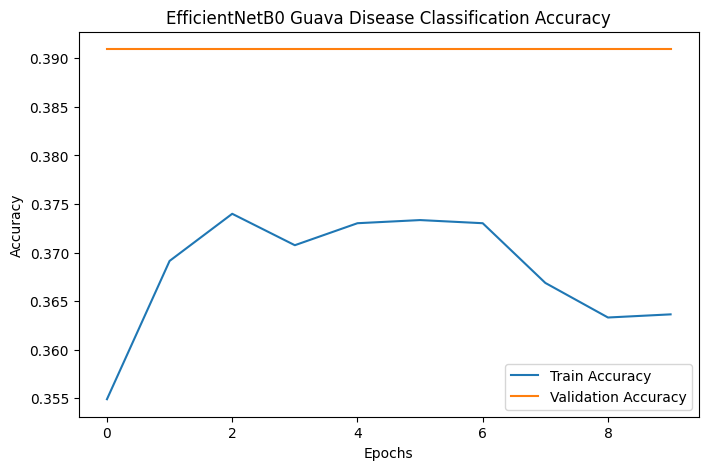

In [1]:
# ============================================================
# 🍃 Guava Disease Classification using EfficientNetB0
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

# ============================================================
# Dataset Paths (UPDATE these paths to your disease dataset)
# ============================================================
train_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\train"
val_dir   = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\val"
test_dir  = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\test"

# ============================================================
# Image Parameters
# ============================================================
img_size = (224, 224)
batch_size = 32
epochs = 50

# ============================================================
# Data Generators
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ============================================================
# Model Definition — EfficientNetB0
# ============================================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Callbacks
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_efficientnet_disease_guava.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# ============================================================
# Training
# ============================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

# ============================================================
# Evaluation on Test Set
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

# ============================================================
# Save Final Model
# ============================================================
model.save("efficientnetB0_disease_guava_final.h5")
print("💾 Model saved as 'efficientnetB0_disease_guava_final.h5'")

# ============================================================
# Plot Accuracy
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('EfficientNetB0 Guava Disease Classification Accuracy')
plt.show()

In [2]:
# ============================================================
# ✅ Training Accuracy Summary
# ============================================================

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"📊 Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"📊 Final Validation Accuracy: {final_val_acc * 100:.2f}%")

📊 Final Training Accuracy: 36.36%
📊 Final Validation Accuracy: 39.09%


In [3]:
# ============================================================
# ✅ Evaluate Model on Test Data
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print("\n📊 ================================")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")
print("📊 ================================")

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.3932 - loss: 1.0879

📊 ================================
✅ Test Accuracy: 39.32%
✅ Test Loss: 1.0879
📊 ================================


✅ Model loaded successfully!
Found 3091 images belonging to 3 classes.
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 358ms/step - accuracy: 0.3921 - loss: 1.0888

🎯 Test Accuracy: 39.21%
📉 Test Loss: 1.0888
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 392ms/step

📊 Classification Report (Test Data):
                         precision    recall  f1-score   support

  Anthracnose_augmented       0.00      0.00      0.00      1005
    fruit_fly_augmented       0.00      0.00      0.00       874
healthy_guava_augmented       0.39      1.00      0.56      1212

               accuracy                           0.39      3091
              macro avg       0.13      0.33      0.19      3091
           weighted avg       0.15      0.39      0.22      3091



c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

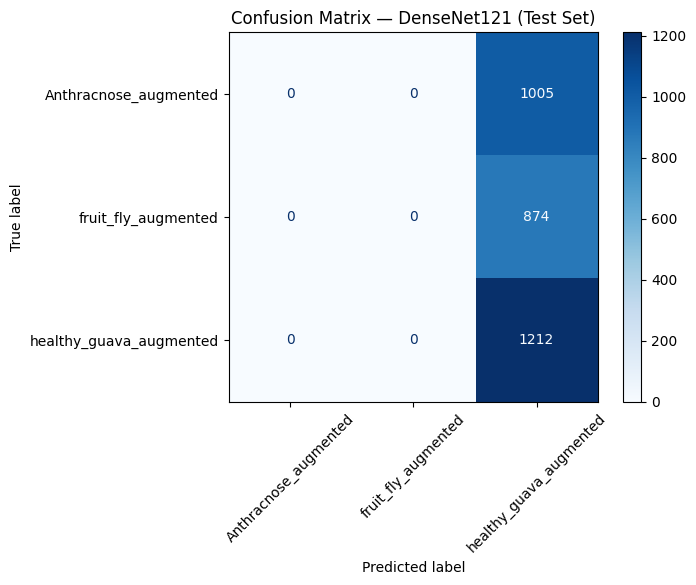

In [1]:
# ============================================================
# 🍃 DenseNet121 — Testing Accuracy Evaluation (Digital Images)
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
test_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\GuavaDiseaseDataset\train"
model_path = "efficientnetB0_disease_guava_final.h5" # or use "densenet121_digital_guava_final.h5"

# ============================================================
# Load Model
# ============================================================
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ============================================================
# Test Data Generator
# ============================================================
img_size = (224, 224)
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ============================================================
# Evaluate on Test Set
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

# ============================================================
# Predictions & Detailed Metrics
# ============================================================
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification Report
print("\n📊 Classification Report (Test Data):")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — DenseNet121 (Test Set)")
plt.show()